# Day 11: NGBoost Distributional Forecast-Error Model

This notebook documents the Day 11 work: training the first NGBoost / distributional GBM model for `forecast_error`.

The target is:

`forecast_error = actual_high - forecast_high`

The model learns a Normal predictive distribution for each prediction row:

`forecast_error | X_t ~ Normal(mu(X_t), sigma(X_t))`

This is still the probability-signal layer. It does not include trading rules, market prices, fees, spreads, or liquidity.

## What Was Added Today

Day 11 added a narrow distributional modeling layer on top of the existing Day 8 feature table.

Created files:

- `src/splits.py`: chronological train / validation / test splitting.
- `src/distributional_model.py`: NGBoost Normal utilities and Normal NLL scoring.
- `src/train_ngboost.py`: runnable Day 11 training pipeline.
- `tests/test_day11_ngboost_setup.py`: guardrail tests for splitting, feature safety, and NLL math.
- `models/ngboost_normal_v0.pkl`: trained model artifact plus imputer and metadata.
- `models/ngboost_normal_v0_features.json`: feature list used by this model.
- `outputs/ngboost_distribution_params_v0.csv`: validation/test row predictions with `mu`, `sigma`, and `nll`.
- `outputs/ngboost_nll_v0.json`: metrics, split summary, sigma summary, and notes.

The split is chronological, not random. The model trains on older dates, validates on later dates, and tests on the newest dates.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Make the notebook work whether it is launched from the repo root or notebooks/.
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

MODELS_DIR = REPO_ROOT / "models"
OUTPUTS_DIR = REPO_ROOT / "outputs"

MODEL_PATH = MODELS_DIR / "ngboost_normal_v0.pkl"
FEATURES_PATH = MODELS_DIR / "ngboost_normal_v0_features.json"
PARAMS_PATH = OUTPUTS_DIR / "ngboost_distribution_params_v0.csv"
METRICS_PATH = OUTPUTS_DIR / "ngboost_nll_v0.json"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
plt.style.use("default")

print(f"Repo root: {REPO_ROOT}")

Repo root: c:\Weather Trading\Kalshi-Weather-Trading


## Load The Day 11 Artifacts

The notebook reads the artifacts saved by `python -m src.train_ngboost`. If this cell fails because `ngboost` is missing, install it with:

`python -m pip install ngboost`

In [2]:
for path in [MODEL_PATH, FEATURES_PATH, PARAMS_PATH, METRICS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing expected Day 11 artifact: {path}")

metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
features_payload = json.loads(FEATURES_PATH.read_text(encoding="utf-8"))

header = pd.read_csv(PARAMS_PATH, nrows=0)
date_columns = [
    column
    for column in ["date", "timestamp", "prediction_time", "prediction_timestamp"]
    if column in header.columns
]
predictions = pd.read_csv(PARAMS_PATH, parse_dates=date_columns)

try:
    with MODEL_PATH.open("rb") as file:
        model_artifact = pickle.load(file)
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Loading the model artifact requires ngboost. Install it with `python -m pip install ngboost`."
    ) from exc

model = model_artifact["model"]
feature_columns = list(model_artifact["feature_columns"])

print(f"Predictions rows: {len(predictions):,}")
print(f"Feature count: {len(feature_columns):,}")
display(predictions.head())

Predictions rows: 20,904
Feature count: 39


,split,date,timestamp,prediction_time,prediction_timestamp,location,forecast_high,actual_high,forecast_horizon_hours,forecast_error,mu,sigma,nll
0,validation,2024-01-01,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,NYC,46.0,45.4,15.0,-0.6,-0.589201,1.461198,1.298222
1,validation,2024-01-01,2024-01-01 01:00:00,2024-01-01 01:00:00,2024-01-01 01:00:00,NYC,46.0,45.4,14.0,-0.6,-0.998851,1.461198,1.335449
2,validation,2024-01-01,2024-01-01 02:00:00,2024-01-01 02:00:00,2024-01-01 02:00:00,NYC,46.0,45.4,13.0,-0.6,-0.730148,1.461198,1.302162
3,validation,2024-01-01,2024-01-01 03:00:00,2024-01-01 03:00:00,2024-01-01 03:00:00,NYC,46.0,45.4,12.0,-0.6,-0.606064,1.461198,1.298204
4,validation,2024-01-01,2024-01-01 04:00:00,2024-01-01 04:00:00,2024-01-01 04:00:00,NYC,46.0,45.4,11.0,-0.6,-0.698531,1.494897,1.323168


## Chronological Split

The model uses a time-based split to avoid training on future data. This is important because weather regimes and forecast behavior change over time, and random splitting would leak future conditions into training.

,row_count,date_min,date_max,duration_days
train,17520,2022-01-01,2023-12-31,730
validation,8784,2024-01-01,2024-12-31,366
test,12120,2025-01-01,2026-05-20,505


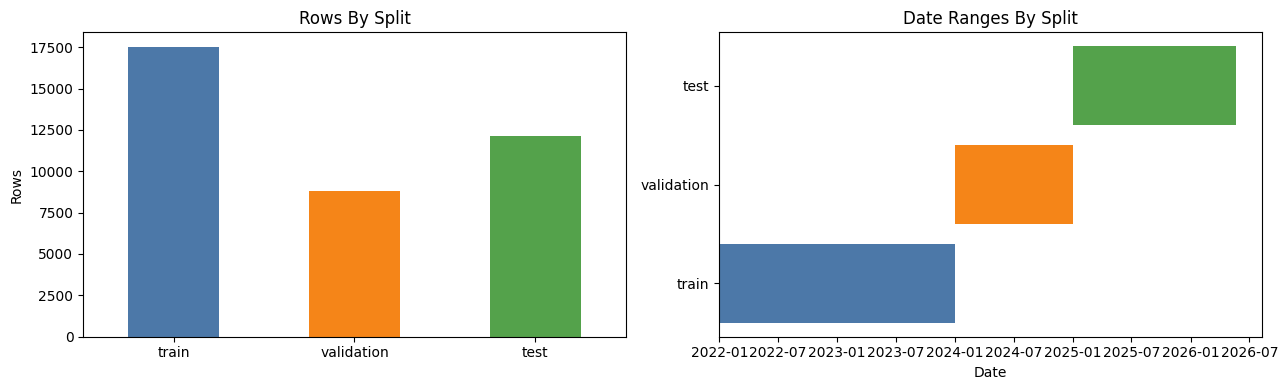

In [3]:
split_summary = metrics["split_summary"]["splits"]
split_df = pd.DataFrame.from_dict(split_summary, orient="index")
split_df["date_min"] = pd.to_datetime(split_df["date_min"])
split_df["date_max"] = pd.to_datetime(split_df["date_max"])
split_df["duration_days"] = (split_df["date_max"] - split_df["date_min"]).dt.days + 1
display(split_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
split_df["row_count"].plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Rows By Split")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=0)

for index, (split_name, row) in enumerate(split_df.iterrows()):
    axes[1].barh(
        y=index,
        width=row["duration_days"],
        left=mdates.date2num(row["date_min"]),
        color={"train": "#4C78A8", "validation": "#F58518", "test": "#54A24B"}[split_name],
    )
axes[1].set_yticks(range(len(split_df)))
axes[1].set_yticklabels(split_df.index)
axes[1].xaxis_date()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].set_title("Date Ranges By Split")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## NLL Results

Negative log likelihood, or NLL, scores the full continuous density. Lower is better.

The comparison baseline is a constant Normal distribution using only the train target mean and train target standard deviation. If NGBoost beats that baseline out of sample, it means the features are learning useful conditional structure beyond the unconditional historical error distribution.

,split,ngboost_nll,constant_normal_nll,improvement_vs_baseline
0,validation,1.324001,2.147658,0.823657
1,test,1.685494,2.408487,0.722993


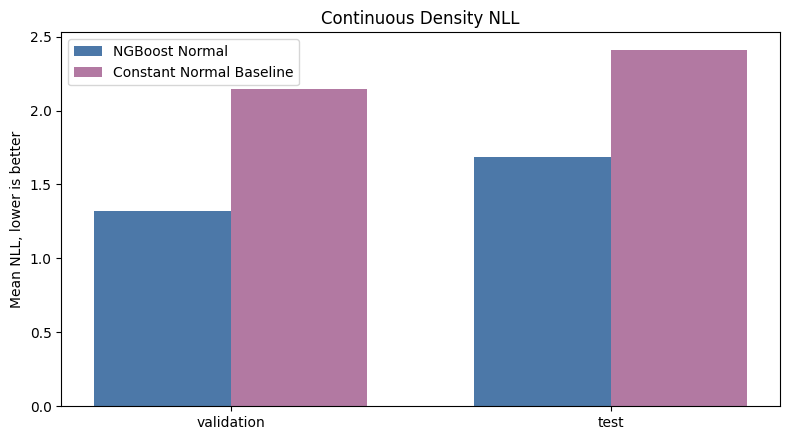

In [4]:
nll_df = pd.DataFrame(
    {
        "split": ["validation", "test"],
        "ngboost_nll": [metrics["validation_ngboost_nll"], metrics["test_ngboost_nll"]],
        "constant_normal_nll": [
            metrics["validation_constant_normal_baseline_nll"],
            metrics["test_constant_normal_baseline_nll"],
        ],
    }
)
nll_df["improvement_vs_baseline"] = nll_df["constant_normal_nll"] - nll_df["ngboost_nll"]
display(nll_df)

x = np.arange(len(nll_df))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, nll_df["ngboost_nll"], width, label="NGBoost Normal", color="#4C78A8")
ax.bar(x + width / 2, nll_df["constant_normal_nll"], width, label="Constant Normal Baseline", color="#B279A2")
ax.set_xticks(x)
ax.set_xticklabels(nll_df["split"])
ax.set_ylabel("Mean NLL, lower is better")
ax.set_title("Continuous Density NLL")
ax.legend()
plt.tight_layout()
plt.show()

## Predicted Distribution Parameters

For every validation and test row, NGBoost predicts:

- `mu`: expected forecast error.
- `sigma`: model uncertainty for forecast error.

Healthy first signs: `sigma` should be positive, finite, and not collapsed near zero.

,min,median,mean,max,near_zero_share_lt_1e-4
validation,0.23345,1.332186,1.097974,2.553268,0.0
test,0.23345,1.331375,1.112200,2.752370,0.0


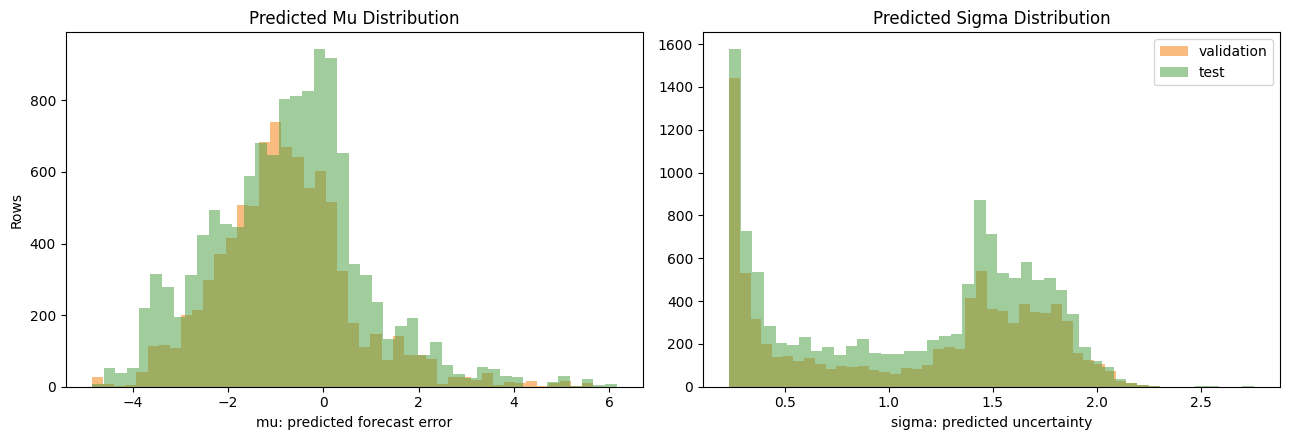

In [5]:
sigma_summary = pd.DataFrame(metrics["sigma_summary"]).T
display(sigma_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for split_name, color in [("validation", "#F58518"), ("test", "#54A24B")]:
    subset = predictions[predictions["split"] == split_name]
    axes[0].hist(subset["mu"], bins=45, alpha=0.55, label=split_name, color=color)
    axes[1].hist(subset["sigma"], bins=45, alpha=0.55, label=split_name, color=color)

axes[0].set_title("Predicted Mu Distribution")
axes[0].set_xlabel("mu: predicted forecast error")
axes[0].set_ylabel("Rows")
axes[1].set_title("Predicted Sigma Distribution")
axes[1].set_xlabel("sigma: predicted uncertainty")
axes[1].legend()
plt.tight_layout()
plt.show()

## Prediction Diagnostics

The scatter plot checks whether predicted `mu` moves with realized `forecast_error`. The residual plot checks whether errors are centered and whether there are large tails to investigate later.

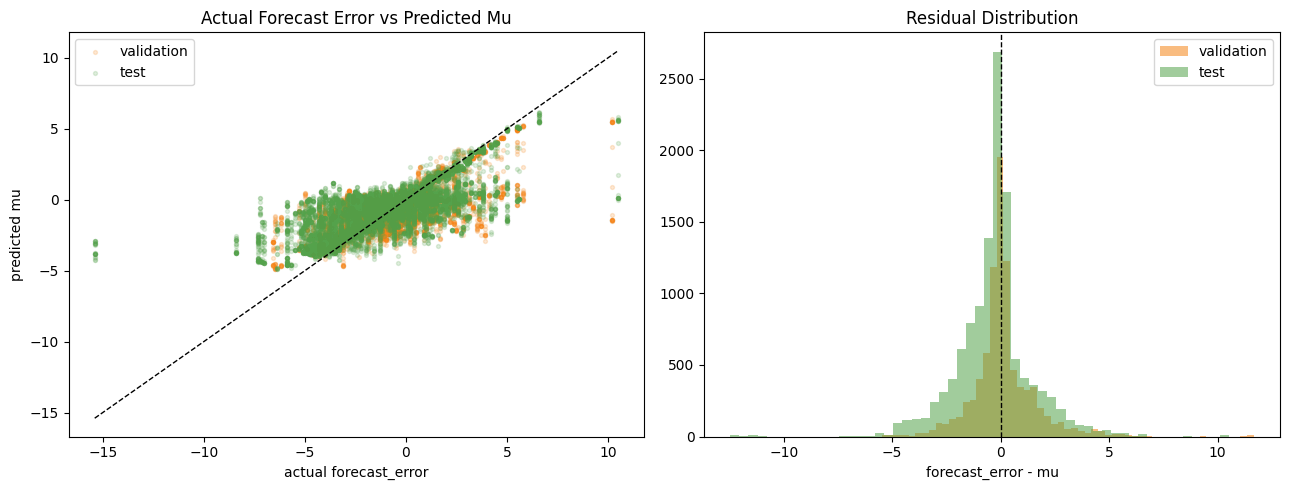

,mean,median,std,min,max
split,,,,,
test,-0.298144,-0.181158,1.763681,-12.457647,10.510092
validation,0.123645,0.007381,1.443786,-5.486665,11.672724


In [6]:
predictions["residual"] = predictions["forecast_error"] - predictions["mu"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split_name, color in [("validation", "#F58518"), ("test", "#54A24B")]:
    subset = predictions[predictions["split"] == split_name]
    axes[0].scatter(subset["forecast_error"], subset["mu"], s=8, alpha=0.18, label=split_name, color=color)
    axes[1].hist(subset["residual"], bins=55, alpha=0.55, label=split_name, color=color)

low = min(predictions["forecast_error"].min(), predictions["mu"].min())
high = max(predictions["forecast_error"].max(), predictions["mu"].max())
axes[0].plot([low, high], [low, high], color="black", linewidth=1, linestyle="--")
axes[0].set_title("Actual Forecast Error vs Predicted Mu")
axes[0].set_xlabel("actual forecast_error")
axes[0].set_ylabel("predicted mu")
axes[0].legend()

axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("forecast_error - mu")
axes[1].legend()
plt.tight_layout()
plt.show()

residual_summary = predictions.groupby("split")["residual"].agg(["mean", "median", "std", "min", "max"])
display(residual_summary)

## NLL Over Time

A model can look good on average while struggling during certain periods. This chart shows daily mean NLL with a rolling average so we can spot rough patches.

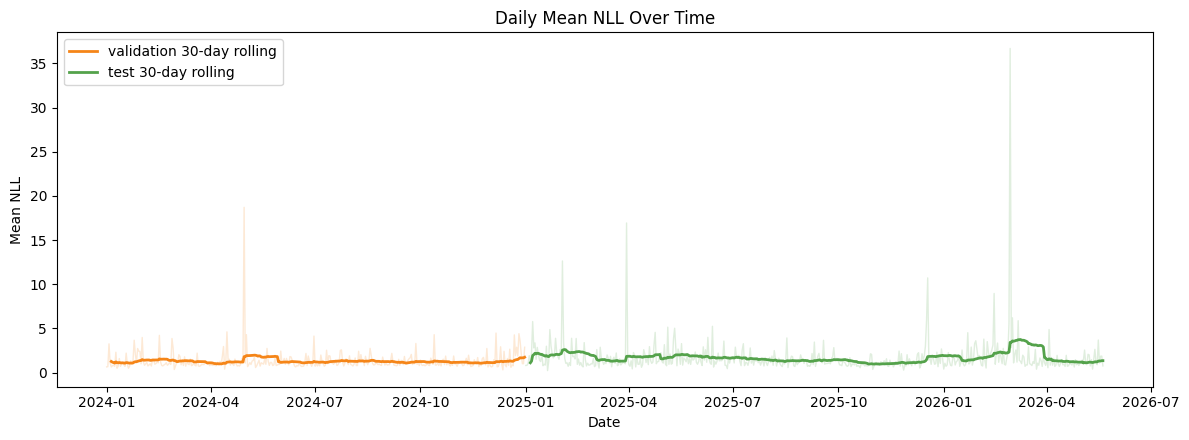

In [7]:
daily_nll = (
    predictions.groupby(["split", "date"], as_index=False)
    .agg(mean_nll=("nll", "mean"), mean_sigma=("sigma", "mean"), mean_abs_error=("residual", lambda x: np.mean(np.abs(x))))
    .sort_values(["split", "date"])
)
daily_nll["rolling_30d_nll"] = daily_nll.groupby("split")["mean_nll"].transform(
    lambda series: series.rolling(30, min_periods=5).mean()
)

fig, ax = plt.subplots(figsize=(12, 4.5))
for split_name, color in [("validation", "#F58518"), ("test", "#54A24B")]:
    subset = daily_nll[daily_nll["split"] == split_name]
    ax.plot(subset["date"], subset["mean_nll"], color=color, alpha=0.18, linewidth=1)
    ax.plot(subset["date"], subset["rolling_30d_nll"], color=color, linewidth=2, label=f"{split_name} 30-day rolling")

ax.set_title("Daily Mean NLL Over Time")
ax.set_ylabel("Mean NLL")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance

NGBoost exposes feature importances separately for each distribution parameter. For this Normal model:

- row 0 is treated as `mu_importance`, the location/mean model.
- row 1 is treated as `sigma_importance`, the scale/uncertainty model.

These importances are useful for debugging model behavior, but they are not causal proof. A high value means the boosted trees used that feature often or strongly while reducing the training objective.

In [8]:
raw_importances = np.asarray(model.feature_importances_)
if raw_importances.ndim == 2 and raw_importances.shape[0] >= 2:
    importance_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "mu_importance": raw_importances[0],
            "sigma_importance": raw_importances[1],
        }
    )
elif raw_importances.ndim == 1:
    importance_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "mu_importance": raw_importances,
            "sigma_importance": np.nan,
        }
    )
else:
    raise ValueError(f"Unexpected feature_importances_ shape: {raw_importances.shape}")

importance_df["combined_importance"] = importance_df[["mu_importance", "sigma_importance"]].mean(axis=1, skipna=True)
importance_df = importance_df.sort_values("combined_importance", ascending=False).reset_index(drop=True)

display(importance_df.head(15))

,feature,mu_importance,sigma_importance,combined_importance
0,max_so_far_minus_forecast_high,0.308482,0.210189,0.259335
1,temp_range_so_far,0.150054,0.096452,0.123253
2,near_boundary_duration_so_far,0.039186,0.176661,0.107923
3,max_temp_error_so_far,0.121452,0.030873,0.076162
4,minutes_until_typical_peak,0.007700,0.142507,0.075103
5,max_so_far_minus_forecast_max_so_far,0.133644,0.010013,0.071828
6,forecast_horizon_hours,0.017322,0.120614,0.068968
7,current_temp_minus_max_so_far,0.002833,0.111482,0.057158
8,forecast_max_so_far,0.055260,0.003104,0.029182
9,day_of_year_cos,0.044210,0.003175,0.023693


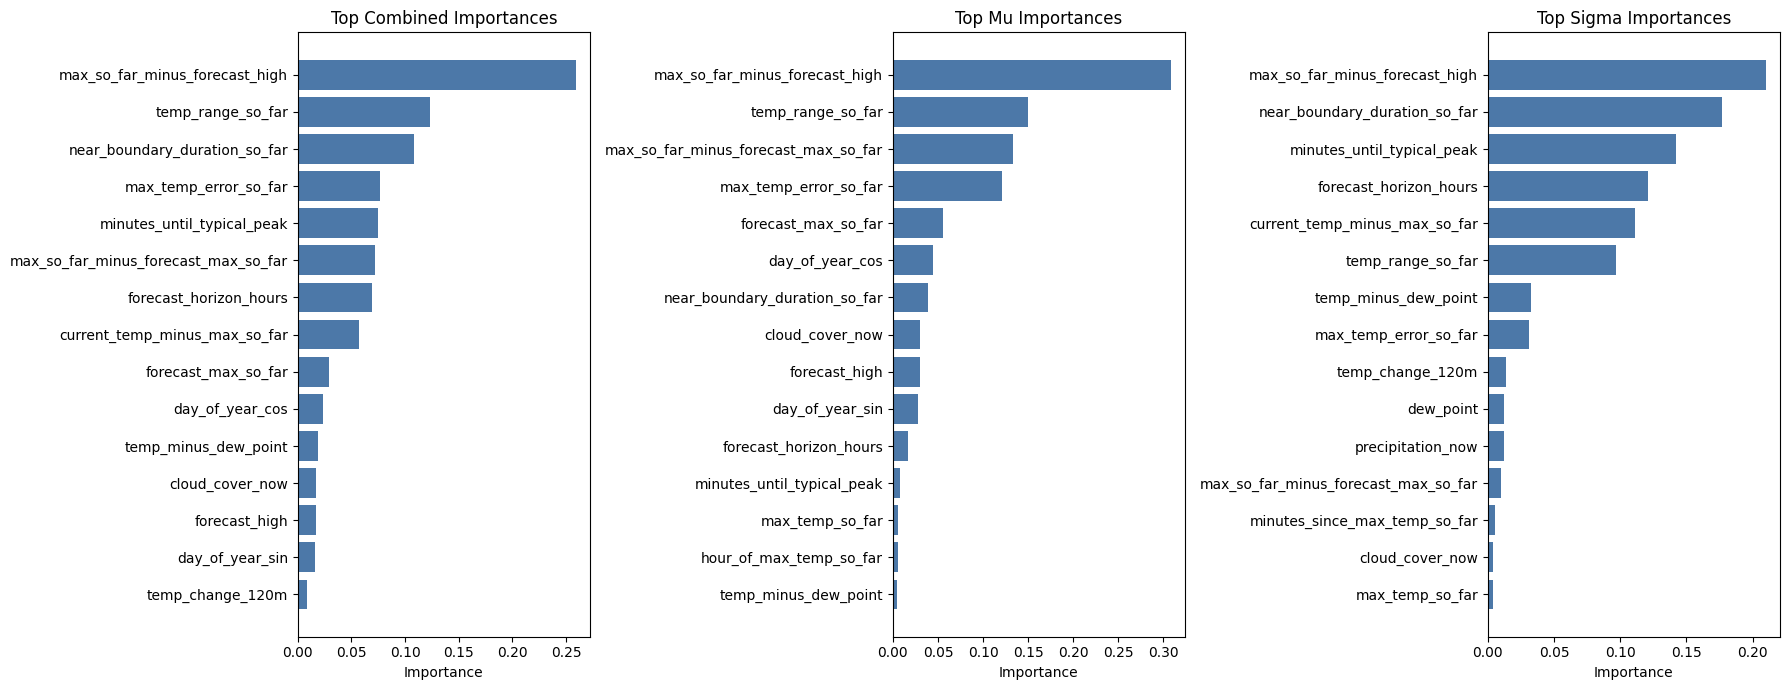

In [9]:
def plot_top_importance(column: str, title: str, ax: plt.Axes, top_n: int = 15) -> None:
    top = importance_df.sort_values(column, ascending=False).head(top_n).sort_values(column)
    ax.barh(top["feature"], top[column], color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Importance")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
plot_top_importance("combined_importance", "Top Combined Importances", axes[0])
plot_top_importance("mu_importance", "Top Mu Importances", axes[1])
plot_top_importance("sigma_importance", "Top Sigma Importances", axes[2])
plt.tight_layout()
plt.show()

## How To Read The Current Top Features

In the current trained artifact, the most important combined features are mostly state-of-day and forecast-relative features:

- `max_so_far_minus_forecast_high`: how far the observed high so far is from the forecast high.
- `temp_range_so_far`: how much temperature has moved during the day so far.
- `near_boundary_duration_so_far`: how often observed temperatures have spent near integer-degree boundaries.
- `max_temp_error_so_far`: how far the observed max-so-far is from the forecast path.
- `minutes_until_typical_peak` and `forecast_horizon_hours`: how much of the day is still unresolved.

That is a healthy first sign: the model is leaning on information available by prediction time, especially how the day is unfolding relative to the forecast.

## Current Read

The first NGBoost model is promising because it beats the train-only constant Normal baseline on validation and test NLL. Its predicted sigmas are positive, finite, and not collapsed near zero.

This does not prove the strategy is tradable. The next modeling check should convert the Normal distributions into bucket probabilities, then evaluate bucket-level calibration with Brier score and bucket log loss before comparing to market prices.